In [ ]:
%run -i ../python_scripts/nb_setup.py

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [8]:
sgp_df = pickle.load(open('../experiments/CIFAR2/sgp_set_cnn','rb')) 
print(sgp_df.shape)
sgp_df.head()

(40000, 3)


,y_true,y_pred,kappa
0,0.0,0.0,0.968736
1,0.0,1.0,0.870544
2,0.0,0.0,0.882295
3,0.0,0.0,0.768718
4,0.0,1.0,0.739913


In [9]:
sgp_df = sgp_df.iloc[:3*int(len(sgp_df)/4)] # train set
sgp_df = sgp_df.sort_values('kappa', ascending=True).reset_index(drop=True).copy()

In [10]:
delta = 0.005

### <font color = 'yellow'> Evolution of bounds with $\theta$

FNR  bounds


  0%|          | 0/50 [00:00<?, ?it/s]

 86%|████████▌ | 43/50 [00:02<00:00, 17.78it/s]


PPV  bounds


 86%|████████▌ | 43/50 [00:13<00:02,  3.27it/s]


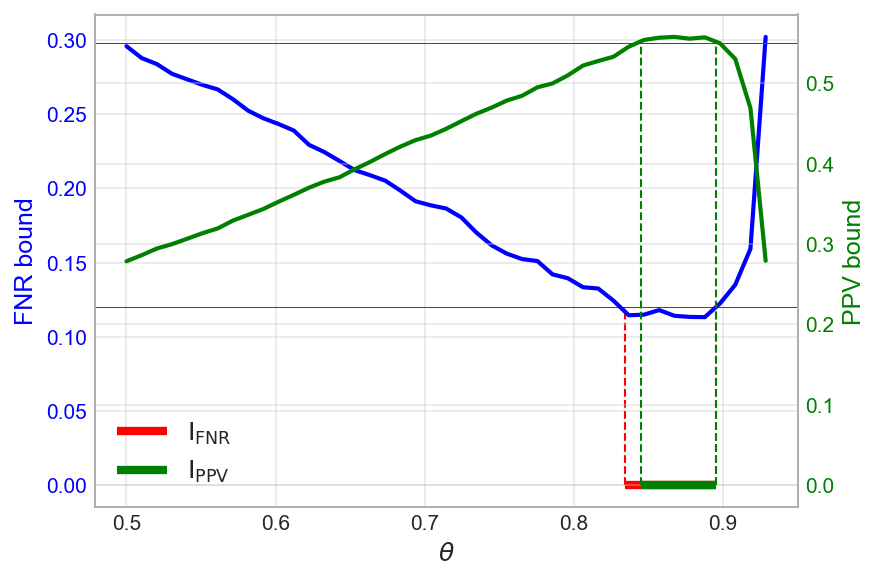

In [11]:
# --- STYLE ONLY (doesn't change logic/data) -------------------------------------
rc = {
    "figure.figsize": (6, 4),
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.facecolor": "white",
    "legend.edgecolor": "#D0D0D0",
    "grid.alpha": 0.45,
}
with plt.rc_context(rc), plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax1 = plt.subplots()

    # make the primary axes look clean
    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_color("#B0B0B0")
        spine.set_linewidth(0.9)
    ax1.xaxis.set_minor_locator(AutoMinorLocator())
    ax1.yaxis.set_minor_locator(AutoMinorLocator())

    # ---- ORIGINAL LOGIC (unchanged) -------------------------------------------
    # First y-axis (FNR)
    thetas, bounds, numerators_fnr, denominators_fnr = bound_evo_w_theta(
        'FNR', sgp_df, delta, steps=50, frac_details=True
    )
    ax1.axhline(0.12, color='r', linewidth=0.5, zorder=1)
    ax1.vlines(0.834, 0, 0.12, colors='r', linewidth=1, linestyle='--', zorder=2)
    ax1.vlines(0.895, 0, 0.12, colors='r', linewidth=1, linestyle='--', zorder=2)
    theta_region_fnr = ax1.hlines(0, 0.834, 0.895, colors='r', linewidth=4, label=r'$\text{I}_{\text{FNR}}$', zorder=3)
    ax1.plot(thetas, bounds, color='blue', linewidth=2, zorder=4)
    ax1.set_xlabel(r'$\theta$')
    ax1.set_ylabel('FNR bound', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Second y-axis (PPV)
    ax2 = ax1.twinx()
    # style the twin axis similarly
    for spine in ax2.spines.values():
        spine.set_visible(True)
        spine.set_color("#B0B0B0")
        spine.set_linewidth(0.9)
    ax2.yaxis.set_minor_locator(AutoMinorLocator())

    thetas, bounds, numerators_ppv, denominators_ppv = bound_evo_w_theta(
        'PPV', sgp_df, delta, steps=50, frac_details=True
    )
    ax2.axhline(0.55, color='green', linewidth=0.5, zorder=1)
    ax2.vlines(0.845, 0, 0.55, colors='green', linewidth=1, linestyle='--', zorder=2)
    ax2.vlines(0.895, 0, 0.55, colors='green', linewidth=1, linestyle='--', zorder=2)
    theta_region_ppv = ax2.hlines(0, 0.845, 0.895, colors='green', linewidth=4, label=r'$\text{I}_{\text{PPV}}$', zorder=3)
    ax2.plot(thetas, bounds, color='green', linewidth=2, zorder=4)
    ax2.set_ylabel('PPV bound', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Show legend
    ax1.legend(handles=[theta_region_fnr, theta_region_ppv], loc='lower left', fontsize=12)

    plt.tight_layout()
    plt.show()

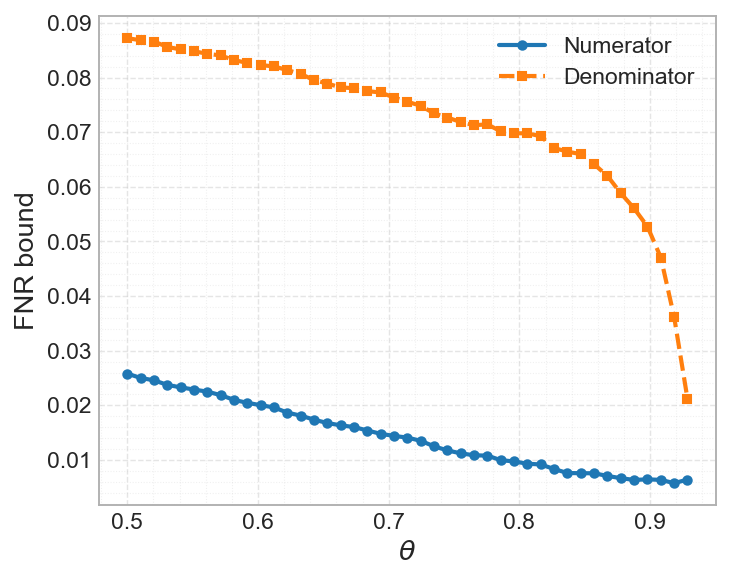

In [16]:
# --- STYLE CONTEXT (visual only) -----------------------------------
rc = {
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.facecolor": "white",
    "legend.edgecolor": "#D0D0D0",
    "grid.alpha": 0.4,
}
with plt.rc_context(rc), plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax = plt.subplots(figsize=(5, 4))

    # Plot with original logic
    ax.plot(
        thetas, numerators_fnr,
        label="Numerator",
        color="tab:blue",
        linestyle="-",
        linewidth=2,
        marker="o",
        markersize=4
    )
    ax.plot(
        thetas, denominators_fnr,
        label="Denominator",
        color="tab:orange",
        linestyle="--",
        linewidth=2,
        marker="s",
        markersize=4
    )

    # Labels and legend
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel("FNR bound")
    ax.legend(fontsize=11, loc="best")

    # Spines, ticks, grid
    for spine in ax.spines.values():
        spine.set_color("#B0B0B0")
        spine.set_linewidth(0.9)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.3)

    plt.tight_layout()
    plt.show()